# Task-3

## Import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression  # Changed from LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             classification_report, precision_score, recall_score,
                             roc_curve, auc, precision_recall_curve, 
                             average_precision_score)
import pickle

## Load the data set

In [3]:
data = pd.read_csv('cleaned_cardio_train.csv')
print("✓ Cleaned data loaded successfully!")
print(f"\nDataset Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

✓ Cleaned data loaded successfully!

Dataset Shape: (61448, 16)
Columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'pulse_pressure', 'age_years', 'map']


In [6]:
## Verify the cleaned data
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nColumn names:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)
print("\nMissing values:")
print(data.isnull().sum())
print("\nTarget distribution:")
print(data['cardio'].value_counts())


Dataset Shape: (61448, 16)

First few rows:
        age  gender    height    weight     ap_hi     ap_lo  cholesterol  \
0 -0.447651       2  0.484402 -0.921091 -1.145538 -0.215593            1   
1  0.299137       1 -1.116139  1.049690  0.961010  1.090662            3   
2 -0.258817       1  0.084267 -0.749719  0.258828 -1.521849            3   
3 -0.761017       2  0.617780  0.792632  1.663193  2.396917            1   
4  0.985287       1 -1.783031 -0.492660 -0.443355 -0.215593            2   

   gluc  smoke  alco  active  cardio       bmi  pulse_pressure  age_years  \
0     1      0     0       1       0 -1.142959       -1.413054  -0.447651   
1     1      0     0       1       1  1.813119        0.514256   0.299137   
2     1      0     0       0       1 -0.791556        1.477910  -0.258817   
3     1      0     0       1       1  0.395084        0.514256  -0.761017   
4     2      0     0       0       0  0.548856       -0.449399   0.985287   

        map  
0 -0.718773  
1  1.11

In [7]:
# Convert age from days to years and round to nearest integer
data['age_years'] = round(data['age'] / 365.25).astype(int)  # Use 365.25 to account for leap years
data.drop(columns=['age'], inplace=True)

In [8]:
X = data.drop(columns=['cardio'])
y = data['cardio']
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())


Features shape: (61448, 14)
Target shape: (61448,)

Feature columns:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'age_years', 'map']


## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scaling

In [10]:
## Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n✓ Features scaled successfully")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")


✓ Features scaled successfully
Scaled training set shape: (49158, 14)
Scaled test set shape: (12290, 14)


## Model 

In [11]:
print("\n" + "="*70)
print("TRAINING INITIAL MODEL")
print("="*70)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)


TRAINING INITIAL MODEL


LogisticRegression(max_iter=1000, random_state=42)

## Predictions

In [12]:
X_train_pred = model.predict(X_train_scaled)
X_test_pred = model.predict(X_test_scaled)
print("✓ Predictions generated")

✓ Predictions generated


## Evaluation Metrics

In [13]:
## Tuned Model Performance

print("="*70)
print("TUNED MODEL PERFORMANCE")
print("="*70)

print("\n" + "="*70)
print("INITIAL MODEL PERFORMANCE")
print("="*70)
print("\n📊 Training Set Metrics:")
print(f"Accuracy: {accuracy_score(y_train, X_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, X_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, X_train_pred):.4f}")
print(f"F1 Score: {f1_score(y_train, X_train_pred):.4f}")

print("\n📊 Test Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test, X_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, X_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, X_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, X_test_pred):.4f}")

print("\n📋 Classification Report (Test Set):")
print(classification_report(y_test, X_test_pred))


TUNED MODEL PERFORMANCE

INITIAL MODEL PERFORMANCE

📊 Training Set Metrics:
Accuracy: 0.7222
Precision: 0.7552
Recall: 0.6434
F1 Score: 0.6948

📊 Test Set Metrics:
Accuracy: 0.7147
Precision: 0.7528
Recall: 0.6247
F1 Score: 0.6828

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      6249
           1       0.75      0.62      0.68      6041

    accuracy                           0.71     12290
   macro avg       0.72      0.71      0.71     12290
weighted avg       0.72      0.71      0.71     12290



## Overfitting / Underfitting Check

In [15]:
## Overfitting / Underfitting Check

train_acc = accuracy_score(y_train, X_train_pred)
test_acc = accuracy_score(y_test, X_test_pred)
print("\n" + "="*70)
print("MODEL FITTING ANALYSIS")
print("="*70)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Difference: {abs(train_acc - test_acc):.4f}")

if abs(train_acc - test_acc) < 0.05:
    print("\n✓ Model Status: Well Generalized (No Overfitting)")
elif train_acc > test_acc:
    print("\n⚠ Model Status: Possible Overfitting")
else:
    print("\n⚠ Model Status: Possible Underfitting")


MODEL FITTING ANALYSIS

Training Accuracy: 0.7222
Test Accuracy: 0.7147
Difference: 0.0075

✓ Model Status: Well Generalized (No Overfitting)


## Hyperparameter Tuning

In [49]:
## Hyperparameter Tuning with GridSearchCV

print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
print(f"\nParameter Grid: {param_grid}")

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("HYPERPARAMETER TUNING RESULTS")
print("="*70)
print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid.best_score_:.4f}")

best_model = grid.best_estimator_


HYPERPARAMETER TUNING

Parameter Grid: {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}
Fitting 5 folds for each of 10 candidates, totalling 50 fits

HYPERPARAMETER TUNING RESULTS

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation F1 Score: 0.7011


## Cross validation results

In [50]:
## Cross-Validation Analysis
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70)
print(f"\nCV F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: {cv_scores.mean():.4f} ± {cv_scores.std() * 2:.4f}")


CROSS-VALIDATION RESULTS

CV F1 Scores: [0.69667362 0.71215634 0.69216147 0.69980163 0.70451784]
Mean CV F1 Score: 0.7011
Std Dev: 0.0069
95% Confidence Interval: 0.7011 ± 0.0137


## Evaluate Tuned Model

In [51]:
## Tuned Model Predictions
best_train_pred = best_model.predict(X_train_scaled)
best_test_pred = best_model.predict(X_test_scaled)
print("\n✓ Tuned model predictions generated")


✓ Tuned model predictions generated


In [52]:
# Tuned Model Performance
print("\n" + "="*70)
print("TUNED MODEL PERFORMANCE")
print("="*70)
print("\n📊 Training Set Metrics:")
print(f"Accuracy: {accuracy_score(y_train, best_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, best_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, best_train_pred):.4f}")
print(f"F1 Score: {f1_score(y_train, best_train_pred):.4f}")

print("\n📊 Test Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test, best_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, best_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, best_test_pred):.4f}")

print("\n📋 Classification Report (Test Set):")
print(classification_report(y_test, best_test_pred))


TUNED MODEL PERFORMANCE

📊 Training Set Metrics:
Accuracy: 0.7244
Precision: 0.7519
Recall: 0.6557
F1 Score: 0.7005

📊 Test Set Metrics:
Accuracy: 0.7178
Precision: 0.7491
Recall: 0.6405
F1 Score: 0.6905

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6249
           1       0.75      0.64      0.69      6041

    accuracy                           0.72     12290
   macro avg       0.72      0.72      0.72     12290
weighted avg       0.72      0.72      0.72     12290



# Task-4

## Confusion Matrix

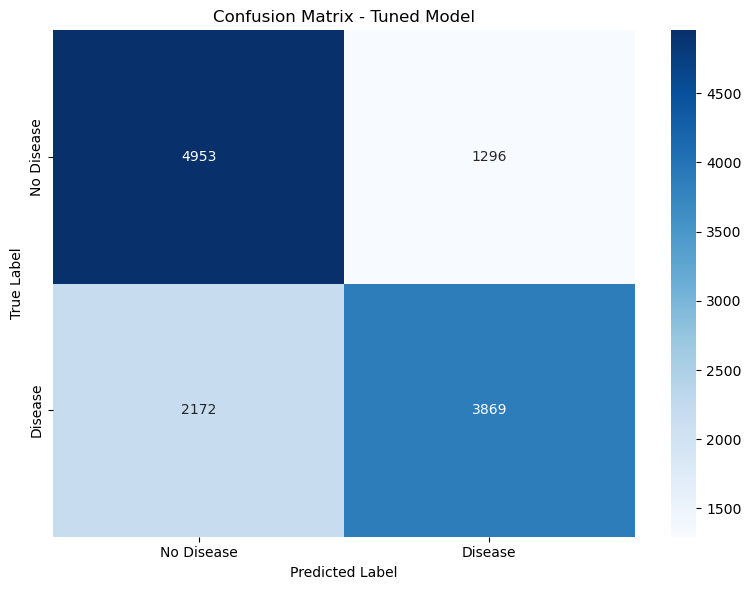


True Negatives:  4953
False Positives: 1296
False Negatives: 2172
True Positives:  3869


In [53]:
## Confusion Matrix Visualization

cm = confusion_matrix(y_test, best_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned Model")
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

## ROC Curve

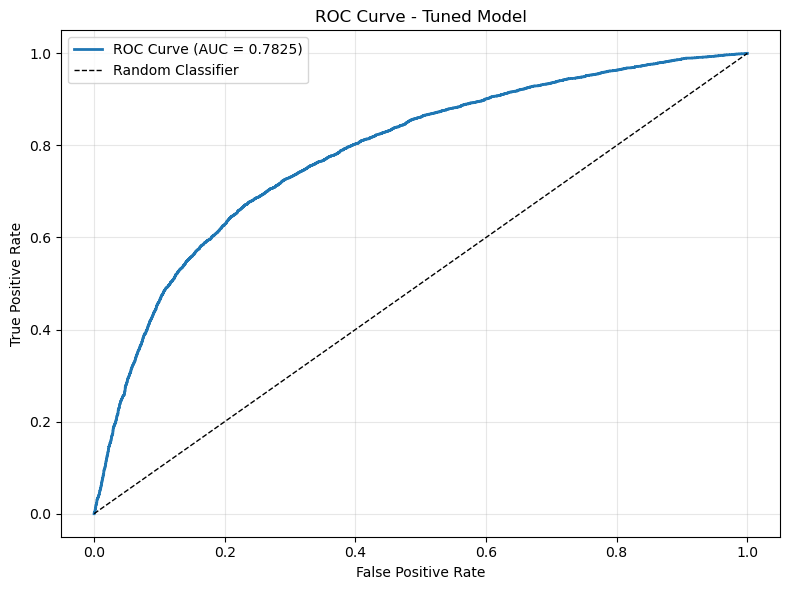

ROC-AUC Score: 0.7825


In [54]:
## ROC Curv
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## Precision–Recall Curve

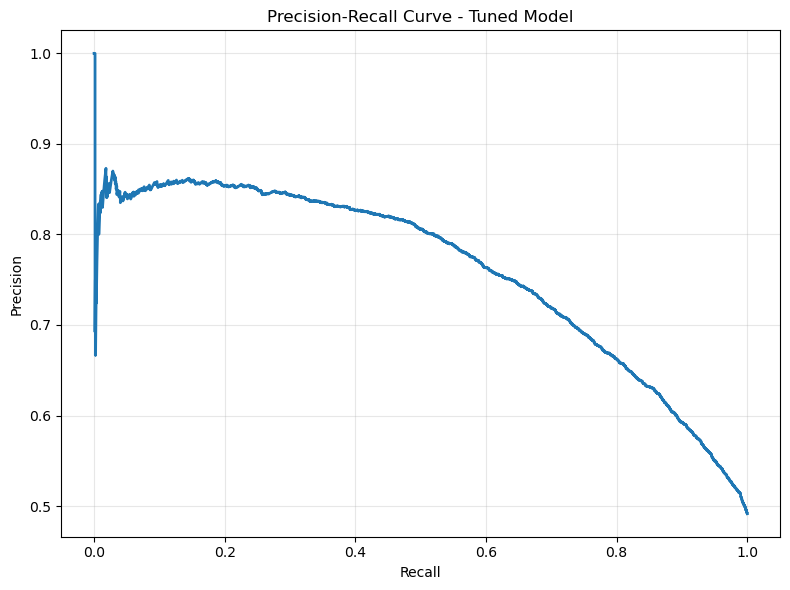

Average Precision Score: 0.7607


In [55]:
from sklearn.metrics import precision_recall_curve
## Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tuned Model')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate average precision
from sklearn.metrics import average_precision_score
avg_precision = average_precision_score(y_test, y_prob)
print(f"Average Precision Score: {avg_precision:.4f}")

## Metrics Comparison Bar Chart

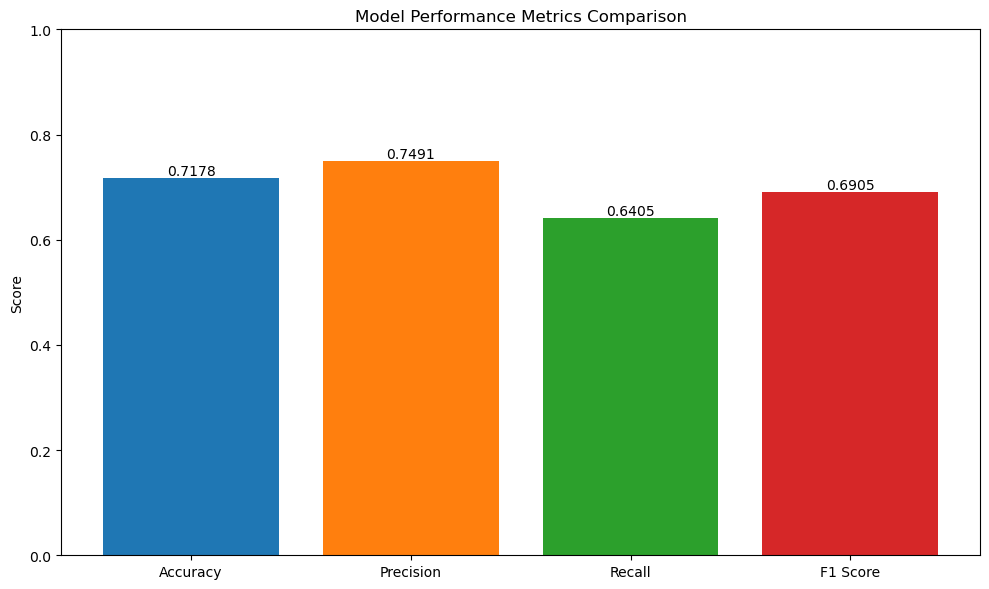

In [56]:
## Performance Metrics Comparison
metrics = {
    'Accuracy': accuracy_score(y_test, best_test_pred),
    'Precision': precision_score(y_test, best_test_pred),
    'Recall': recall_score(y_test, best_test_pred),
    'F1 Score': f1_score(y_test, best_test_pred)
}

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylabel('Score')
plt.title('Model Performance Metrics Comparison')
plt.ylim(0, 1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Learning Curve (Overfitting / Underfitting Proof)

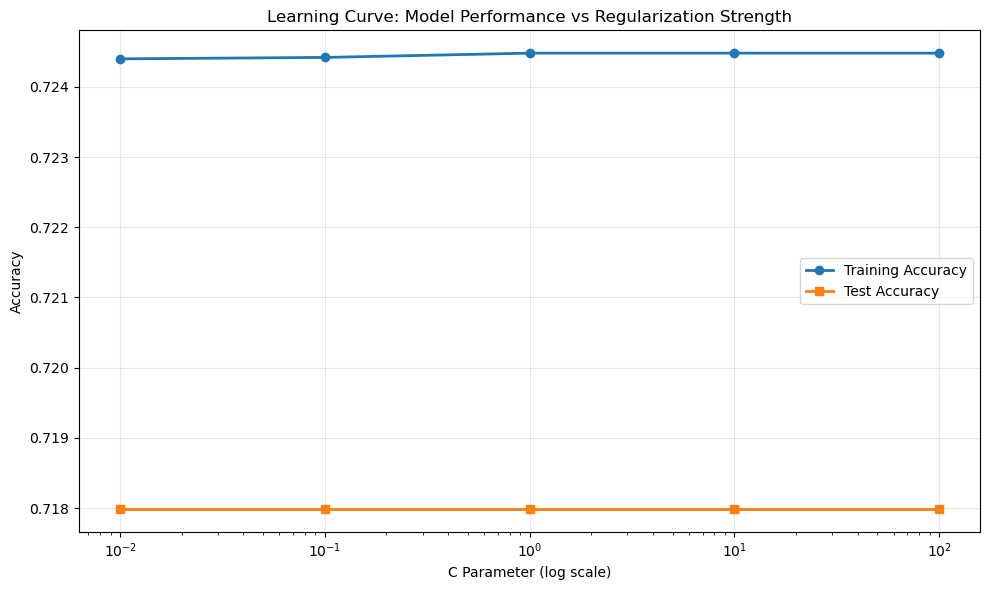

C values: [0.01, 0.1, 1, 10, 100]
Training Accuracies: ['0.7244', '0.7244', '0.7245', '0.7245', '0.7245']
Test Accuracies: ['0.7180', '0.7180', '0.7180', '0.7180', '0.7180']


In [57]:
## Learning Curve Analysis

C_values = [0.01, 0.1, 1, 10, 100]
train_accuracies = []
test_accuracies = []

for c in C_values:
    temp_model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, temp_model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, temp_model.predict(X_test_scaled))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, 'o-', label='Training Accuracy', linewidth=2)
plt.plot(C_values, test_accuracies, 's-', label='Test Accuracy', linewidth=2)
plt.xscale('log')
plt.xlabel('C Parameter (log scale)')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Model Performance vs Regularization Strength')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("C values:", C_values)
print("Training Accuracies:", [f"{acc:.4f}" for acc in train_accuracies])
print("Test Accuracies:", [f"{acc:.4f}" for acc in test_accuracies])

## Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
       Feature  Coefficient  Abs_Coefficient
   cholesterol     0.340704         0.340704
         ap_hi     0.325179         0.325179
pulse_pressure     0.306878         0.306878
           map     0.275584         0.275584
         ap_lo     0.188465         0.188465
     age_years     0.172884         0.172884
           age     0.172884         0.172884
        active    -0.096204         0.096204
        weight     0.090533         0.090533
          gluc    -0.063793         0.063793


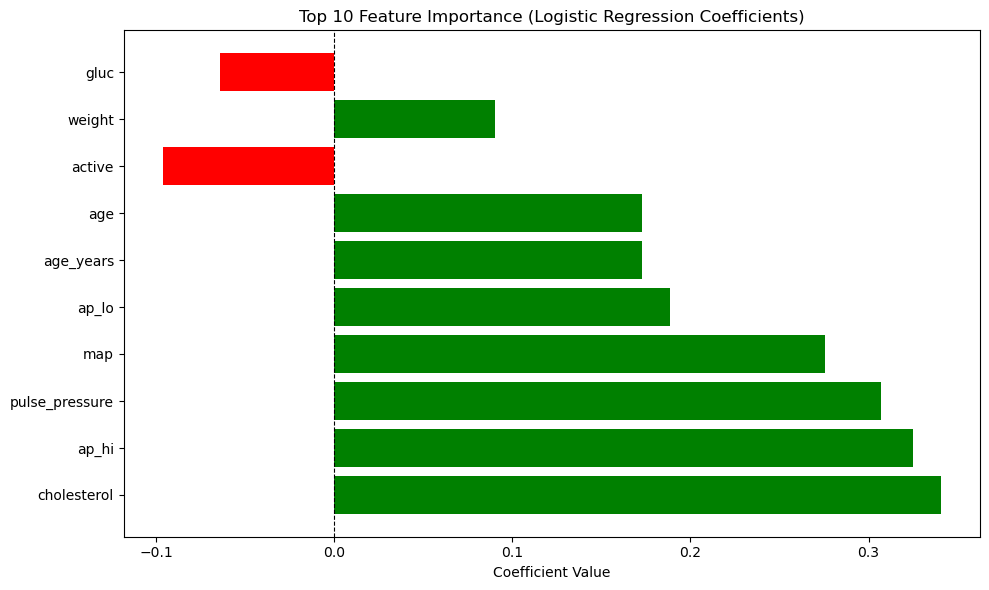

In [59]:
## Feature Importance Analysis

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import OneHotEncoder
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']
encoder = OneHotEncoder(handle_unknown='ignore')

cat_encoded = encoder.fit_transform(data[cat_cols])
print('Encoded Shape:',cat_encoded.shape)

Encoded Shape: (61448, 14)


In [16]:
# Save model and preprocessing objects for Streamlit
print("🔄 Saving model and preprocessors for Streamlit app...")

# Save the trained model
pickle.dump(model, open('cardio_model.pkl', 'wb'))
print("✅ Model saved: cardio_model.pkl")

# Save scaler (for numerical features)
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("✅ Scaler saved: scaler.pkl")

# Save encoder (for categorical features)
pickle.dump(encoder, open('encoder.pkl', 'wb'))
print("✅ Encoder saved: scaler.pkl")

print("🎉 All files ready for Streamlit deployment!")
print("📁 Files created: cardio_model.pkl, scaler.pkl, encoder.pkl")


🔄 Saving model and preprocessors for Streamlit app...
✅ Model saved: cardio_model.pkl
✅ Scaler saved: scaler.pkl
✅ Encoder saved: scaler.pkl
🎉 All files ready for Streamlit deployment!
📁 Files created: cardio_model.pkl, scaler.pkl, encoder.pkl
